[*********************100%***********************]  6 of 6 completed


United Kingdom Data Loaded!
Ticker             AZN.L      BARC.L        BP.L       HSBA.L       SHEL.L      TSCO.L
Date                                                                                  
2025-09-29  11086.862305  380.756104  434.435059  1039.598145  2695.253174  440.560272
2025-09-30  11180.852539  379.556274  425.588409  1044.596191  2645.766602  445.358734
2025-10-01  12434.723633  380.156219  427.587616  1050.394043  2679.757080  429.563721
2025-10-02  12452.721680  380.256165  422.339630  1043.196777  2669.759766  452.256531
2025-10-03  12648.701172  385.305603  423.589172  1061.389771  2701.750977  448.557739

--- Average Daily Returns / Mean Returns (Drift) ---
Ticker
AZN.L     0.000799
BARC.L    0.001520
BP.L      0.001392
HSBA.L    0.002026
SHEL.L    0.001160
TSCO.L    0.000479
dtype: float64

--- Covariance Matrix (How they move together) ---
Ticker     AZN.L    BARC.L      BP.L    HSBA.L    SHEL.L    TSCO.L
Ticker                                                

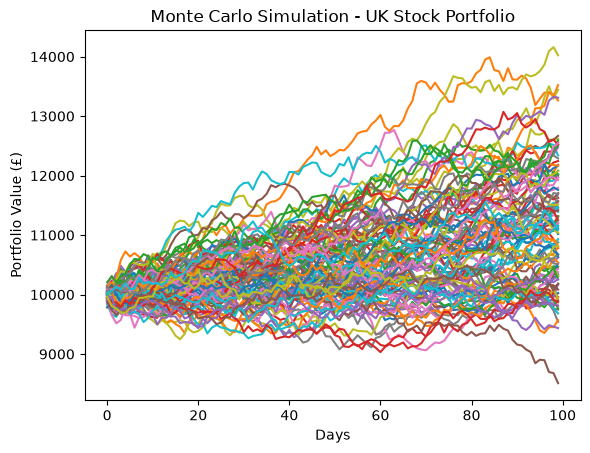

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

pd.set_option('display.expand_frame_repr', False) # no text wrapping, prints in continuous lines

# Aus stock list
stockList = ['BARC' , 'BP' , 'TSCO' , 'AZN' , 'HSBA' , 'SHEL']
# Add the .L suffix to all above name using a for loop (London stock exchange)
stocks = [stock + '.L' for stock in stockList] 


# 300-day time window
endDate = dt.datetime.now()                     # pings computer's internal clock and stamps the exact current date and time as end point
startDate = endDate - dt.timedelta(days=300)    # subtracts 300 days from the current endDate, .timedelta is time measurement (days / hours / seconds etc..)



# Modern download method
stockData = yf.download(stocks, start=startDate, end=endDate)['Close']  # uses yfinance library to connect to servers to extract .L ticker within my time bracket 
                                                                        # servers spreadsheet contains open, close and volume for each stock. Monte Carlo simulation cares only for end-of-day value (Close)


# Math setup
# cannot run simulations on raw dollar amounts because a $5 drop means different for a $10 stock and $100 stock, so normalisation is required

returns = stockData.pct_change()        # calculates the daily percentage return. Instead of $40 -> $41, we get +2.5%. (Normalises everything)
meanReturns = returns.mean()            # calculates the single avg of daily percentage change for each stock over last 300 days (aka DRIFT in finance)
covMatrix = returns.cov()               # (covariance matrix) calculates how these stocks move in relation to another. To ensure Monte Carlo Sim respects real-world market gravity



print("United Kingdom Data Loaded!")
print(stockData.head())

print("\n--- Average Daily Returns / Mean Returns (Drift) ---")
print(meanReturns)

print("\n--- Covariance Matrix (How they move together) ---")
print(covMatrix)

# Figuring out, how much out of your total money to invest in each stock.
weights = np.random.random(len(meanReturns))    # generates random numbers between 0-1 (6 numbers - the length of meanReturns)
                                                # sum of the above 6 numbers may exceed 1 (100%), which doesn't make sense as you can't invest more than you have
weights /= np.sum(weights)                      # /= shortcut to divide every single number in the above list and divide by its total sum

print ("\n--- Weights ---")
print (weights)



# MONTE CARLO METHOD
# Number of Simulations
mc_sims = 100                   # assigns a number to variable mc_sims (number of times the simulation will run)
# Time frame in days
T = 100                         # sets the time frame to number of days into the future which the simulation will run

# Pre-Building the Arrays (The Framework)
meanM = np.full(shape=(T , len(weights)), fill_value = meanReturns)
        # np.full() creates a grid with size (Rows length (T) and Columns length (6))
        # fill value tells it to stamp the exact same daily base drift (meanReturns) into every single 600 of those cells in the grid
meanM = meanM.T
        # transpose the meanM grid from 100x6 to a 6x100 grid for later calculations
portfolio_sims = np.full(shape=(T , mc_sims), fill_value = 0.0)
        # uses np.full() again to build an empty storage warehouse. It creates a grid 100days x 100 sims wide. Fills every single cell with 0.0.
        # as the loop runs, it will overwrite the 0.0 values
initialPortfolio = 10000
        # simply stores my starting cash value (£10,000)

# For Loop (The Assembly Line)
for m in range(0, mc_sims):                          # m will take up the value from 0 _> mc_sims in each loop
    Z = np.random.normal(size=(T, len (weights)))    # np.random.normal generates values strictly from a standard bell curve (mean 0, std dev 1) of the given grid size (100x6)
    L = np.linalg.cholesky(covMatrix)                # executes cholesky decomposition on to our covMatrix (refer extra MATH notes)
    dailyReturns = meanM + np.inner(L, Z)            # 

    portfolio_sims[:, m] = np.cumprod(np.inner(weights, dailyReturns.T) + 1) * initialPortfolio


# Visualisation
plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value (£)')
plt.xlabel('Days')
plt.title('Monte Carlo Simulation - UK Stock Portfolio')
plt.show()